In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install optbinning
import pandas as pd
import numpy as np
from optbinning import OptimalBinning, BinningProcess

In [ ]:
cd /content/drive/MyDrive/learning_work/churn_prediction/assets

/content/drive/MyDrive/learning_work/churn_prediction/assets


In [ ]:
data = pd.read_csv('train_data_V2.csv')
data = data.set_index("user_id")
print(data.shape)
data.head()

,gender,marital_status,individual_income_segment_code,label,sum_amt_Q1,sum_amt_Q2,sum_amt_Q3,sum_amt_Q4,avg_amt_Q1,avg_amt_Q2,...,max_sa_bal_Q3,max_sa_bal_Q4,sa_bal_recent_3m_avg,sa_bal_recent_3m_max,sa_bal_prev_3m_avg,sa_bal_prev_3m_max,sa_bal_3m_avg_diff,sa_bal_3m_avg_ratio,account_aging_month,user_age
user_id,,,,,,,,,,,,,,,,,,,,,
2723,F,2,15,1.0,564528.0,1012963.0,674978.0,1237067.0,70566.000000,63310.187500,...,862413.0,629437.0,288810.000000,629437.0,4.437793e+05,862413.0,-154969.333333,0.650796,470,79.0
44088,M,,03,1.0,472247.0,1250633.0,1134008.0,1295428.0,42931.545455,65822.789474,...,2328823.0,1000964.0,520877.666667,1000964.0,1.295088e+06,2328823.0,-774210.666667,0.402195,385,65.0
3139,F,3,08,0.0,372719.0,603220.0,768056.0,488722.0,37271.900000,46401.538462,...,1099177.0,718667.0,507269.000000,718667.0,6.294283e+05,1099177.0,-122159.333333,0.805920,460,66.0
25596,M,1,03,0.0,642111.0,525513.0,746737.0,452694.0,40131.937500,37536.642857,...,516441.0,129100.0,43033.333333,129100.0,4.146177e+05,516441.0,-371584.333333,0.103790,581,79.0
15409,M,,14,0.0,464573.0,489361.0,626925.0,732213.0,30971.533333,34954.357143,...,717097.0,485440.0,161813.333333,485440.0,4.020730e+05,717097.0,-240259.666667,0.402448,523,70.0


## Feature Selection



> **To select feature before running model using IV score selection (Information value) and Pearson correlation**



In [ ]:
def iv_score(X, y):
    X = X.copy()

    # separate categorical columns and numeric columns
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    # Ensure categorical columns with empty strings are treated as NaN
    for col in categorical_cols:
        if (X[col] == '').any():
            X[col] = X[col].replace('', np.nan)

    # Include the columns to be used.
    use_cols = numeric_cols + categorical_cols
    X = X[use_cols]

    binning_process = BinningProcess(variable_names=use_cols, categorical_variables=categorical_cols,
                                     max_n_bins=5, min_bin_size=0.05, n_jobs=-1)

    binning_process.fit(X, y)
    iv_result = binning_process.summary().sort_values(by="iv", ascending=False).reset_index(drop=True)
    return iv_result, binning_process



> **Firstly, calculate IV score of each features**



In [ ]:
X = data.drop(columns=["label"])
y = data["label"].astype(int)

iv_result, binning_process = iv_score(X, y)
iv_result

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,avg_amt_Q2,numerical,OPTIMAL,True,5,6.339272,0.48407,0.934193,0.0
1,avg_amt_Q3,numerical,OPTIMAL,True,5,5.792549,0.47106,0.927451,0.0
2,avg_amt_Q4,numerical,OPTIMAL,True,5,5.665367,0.450586,0.910883,0.0
3,mcc_total_amt,numerical,OPTIMAL,True,5,5.119345,0.435016,0.889582,0.0
4,avg_amt_Q1,numerical,OPTIMAL,True,5,4.775233,0.384234,0.865131,0.0
...,...,...,...,...,...,...,...,...,...
75,cnt_card_Q3,numerical,OPTIMAL,True,2,0.000045,0.000006,0.002198,0.000003
76,cnt_card_Q4,numerical,OPTIMAL,True,2,0.000045,0.000006,0.002198,0.000003
77,total_cnt_card,numerical,OPTIMAL,True,2,0.000045,0.000006,0.002198,0.000003
78,cnt_card_Q2,numerical,OPTIMAL,True,2,0.000045,0.000006,0.002198,0.000003


In [ ]:
iv_result[(iv_result['iv']<=0.5) & (iv_result['iv']>=0.1)]

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
37,sa_bal_3m_avg_diff,numerical,OPTIMAL,True,5,0.476609,0.056618,0.351268,0.74383
38,user_age,numerical,OPTIMAL,True,5,0.413486,0.049057,0.321133,0.61333
39,sum_amt_3m_ratio,numerical,OPTIMAL,True,5,0.279783,0.030614,0.205093,0.501393
40,mcc_mcc_cat3_ratio,numerical,OPTIMAL,True,5,0.232664,0.026747,0.194949,0.108032
41,mcc_mcc_cat1_ratio,numerical,OPTIMAL,True,5,0.212303,0.025445,0.226775,0.344766
42,mcc_mcc_cat6_ratio,numerical,OPTIMAL,True,4,0.200743,0.023444,0.165363,0.456937
43,mcc_mcc_cat15_ratio,numerical,OPTIMAL,True,5,0.187022,0.022986,0.230981,0.418076
44,mcc_mcc_cat7_ratio,numerical,OPTIMAL,True,5,0.170576,0.019223,0.136137,0.145183
45,mcc_mcc_cat16_ratio,numerical,OPTIMAL,True,5,0.168515,0.018321,0.127409,0.085724
46,mcc_mcc_cat9_ratio,numerical,OPTIMAL,True,3,0.165511,0.018187,0.125106,0.252683




> **Select feature that IV score is between 0.1 - 0.5**

> **Use that feature to find correlation using Pearson correlation**



In [ ]:
col_x = iv_result[(iv_result['dtype'] == 'numerical') & (iv_result['iv']<=0.5) & (iv_result['iv']>=0.1)]['name'].tolist()

corr_df = data[col_x].corr().stack().reset_index()
corr_df.columns = ['var1', 'var2', 'correlation']
corr_df = corr_df[corr_df['var1'] < corr_df['var2']]
corr_df = corr_df.merge(iv_result[['name', 'iv']], left_on = ['var1'], right_on = ['name'], how='left').drop(columns=['name']).rename(columns={'iv':'iv1'})
corr_df = corr_df.merge(iv_result[['name', 'iv']], left_on = ['var2'], right_on = ['name'], how='left').drop(columns=['name']).rename(columns={'iv':'iv2'})

corr_df.sort_values(by='correlation', ascending=False)

,var1,var2,correlation,iv1,iv2
234,util_prev_3m,utilization_ratio_Q3,1.000000,0.119534,0.119534
193,utilization_ratio_Q1,utilization_ratio_Q3,0.796846,0.126744,0.119534
233,util_prev_3m,utilization_ratio_Q1,0.796846,0.119534,0.126744
94,cnt_trans_3m_ratio,sum_amt_3m_ratio,0.778026,0.163727,0.279783
143,mcc_mcc_cat14_ratio,util_prev_3m,0.090484,0.14691,0.119534
...,...,...,...,...,...
133,mcc_mcc_cat14_ratio,mcc_mcc_cat15_ratio,-0.148721,0.14691,0.187022
167,mcc_mcc_cat11_ratio,mcc_mcc_cat3_ratio,-0.166494,0.138786,0.232664
60,mcc_mcc_cat15_ratio,mcc_mcc_cat8_ratio,-0.172368,0.187022,0.120107
250,mcc_mcc_cat12_ratio,mcc_mcc_cat8_ratio,-0.180138,0.117367,0.120107




> **Remove feature after calculating IV score and Pearson correlation**



In [ ]:
def remove(x):
    if x['correlation']>=-0.6 and x['correlation']<=0.6: return np.nan
    elif x['iv1']>=x['iv2']: return x['var2']
    else: return x['var1']

corr_df['remove'] = corr_df.apply(remove, axis=1)
corr_df

,var1,var2,correlation,iv1,iv2,remove
0,sa_bal_3m_avg_diff,user_age,0.010465,0.476609,0.413486,NaN
1,sa_bal_3m_avg_diff,sum_amt_3m_ratio,0.034846,0.476609,0.279783,NaN
2,sa_bal_3m_avg_diff,utilization_ratio_Q1,-0.102997,0.476609,0.126744,NaN
3,sa_bal_3m_avg_diff,utilization_ratio_Q3,-0.053722,0.476609,0.119534,NaN
4,sa_bal_3m_avg_diff,util_prev_3m,-0.053722,0.476609,0.119534,NaN
...,...,...,...,...,...,...
248,mcc_mcc_cat12_ratio,utilization_ratio_Q1,-0.004347,0.117367,0.126744,NaN
249,mcc_mcc_cat12_ratio,mcc_mcc_cat4_ratio,-0.071577,0.117367,0.125943,NaN
250,mcc_mcc_cat12_ratio,mcc_mcc_cat8_ratio,-0.180138,0.117367,0.120107,NaN
251,mcc_mcc_cat12_ratio,utilization_ratio_Q3,-0.015103,0.117367,0.119534,NaN


In [58]:
all_col = set(list(corr_df['var1']) + list(corr_df['var2']))
col_rm = set(list(corr_df['remove']))
col_used = all_col - col_rm
print(f'All Columns: {len(all_col)}')
print(f'Removed Columns: {len(col_rm)}')
print(f'Remaining Columns: {len(col_used)}')
print(col_used)

All Columns: 23
Removed Columns: 4
Remaining Columns: 20
{'mcc_mcc_cat15_ratio', 'mcc_mcc_cat12_ratio', 'mcc_mcc_cat11_ratio', 'mcc_mcc_cat4_ratio', 'mcc_mcc_cat5_ratio', 'mcc_mcc_cat16_ratio', 'mcc_mcc_cat14_ratio', 'user_age', 'cnt_trans_Q1', 'sa_bal_3m_avg_diff', 'utilization_ratio_Q1', 'mcc_mcc_cat1_ratio', 'mcc_mcc_cat8_ratio', 'mcc_mcc_cat3_ratio', 'mcc_mcc_cat2_ratio', 'mcc_mcc_cat10_ratio', 'mcc_mcc_cat9_ratio', 'sum_amt_3m_ratio', 'mcc_mcc_cat7_ratio', 'mcc_mcc_cat6_ratio'}


In [59]:
col_used = list(col_used) + ['individual_income_segment_code', 'label']
data_model = data[col_used]
data_model = data_model.reset_index(drop=True)
data_model.shape

(494, 22)

## Data Transformation



> **Use OneHotEncoder method to convert categorical feature to numeric columns**



In [61]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(data_model[["individual_income_segment_code"]])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["individual_income_segment_code"]))

data_model = pd.concat([data_model, encoded_df], axis=1)
data_model.drop(columns=["individual_income_segment_code"], inplace=True)
data_model.head()

,mcc_mcc_cat15_ratio,mcc_mcc_cat12_ratio,mcc_mcc_cat11_ratio,mcc_mcc_cat4_ratio,mcc_mcc_cat5_ratio,mcc_mcc_cat16_ratio,mcc_mcc_cat14_ratio,user_age,cnt_trans_Q1,sa_bal_3m_avg_diff,...,individual_income_segment_code_06,individual_income_segment_code_07,individual_income_segment_code_08,individual_income_segment_code_09,individual_income_segment_code_10,individual_income_segment_code_11,individual_income_segment_code_12,individual_income_segment_code_13,individual_income_segment_code_14,individual_income_segment_code_15
0,0.032441,0.054771,0.107609,0.085073,0.058001,0.031831,0.024451,79.0,8.0,-154969.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.071182,0.033211,0.011896,0.038727,0.024471,0.081921,0.126561,65.0,11.0,-774210.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.064889,0.069305,0.040538,0.118471,0.030433,0.086542,0.032926,66.0,10.0,-122159.333333,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.090124,0.033544,0.000000,0.090714,0.031602,0.114176,0.072411,79.0,16.0,-371584.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.010185,0.060587,0.003131,0.076404,0.137473,0.105909,0.057872,70.0,15.0,-240259.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Training Model



> **Training model using RandomForest Classifier and XGBoost Classifier**



In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score

In [ ]:
def f2_score(precision, recall):
    return 5 * ((precision * recall) / ((4 * precision) + recall))

In [62]:
X = data_model.drop(columns=['label'])
y = data_model['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(345, 36) (149, 36) (345,) (149,)


### RandomForest

#### Hyperparameter Tuning with GridSearchCV

In [ ]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'min_samples_leaf': [10, 20, 30],
    'class_weight': ['balanced']
}

# Create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring={"roc_auc": "roc_auc",
             "precision": "precision",
             "recall": "recall" },
    refit="roc_auc",
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best ROC AUC score found: ", grid_search.best_score_)

# Get the best model
best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found:  {'class_weight': 'balanced', 'max_depth': 9, 'min_samples_leaf': 10, 'n_estimators': 100}
Best ROC AUC score found:  0.6646701066391468


#### Evaluate the Best Random Forest Model



> **Get AUC, Precision, and Recall value from training model and calculate F2 score**



In [ ]:
best_index = grid_search.best_index_
precision = grid_search.cv_results_["mean_test_precision"][best_index]
recall = grid_search.cv_results_["mean_test_recall"][best_index]

print("Best CV ROC AUC:", grid_search.cv_results_["mean_test_roc_auc"][best_index])
print("Best CV Precision:", precision)
print("Best CV Recall:", recall)
print("F2 score: ", f2_score(precision, recall))

Best CV ROC AUC: 0.6646701066391468
Best CV Precision: 0.4451348651348651
Best CV Recall: 0.2964912280701754
F2 score:  0.31770975639516075


> **Get AUC, Precision, and Recall value of the test data from model and calculate F2 score**

In [ ]:
rf_best_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
rf_best_pred = (rf_best_pred_proba >= 0.5).astype(int)

print("Best Random Forest AUC (Test Set):", roc_auc_score(y_test, rf_best_pred_proba))
print(classification_report(y_test, rf_best_pred))
print(confusion_matrix(y_test, rf_best_pred))

precision = precision_score(y_test, rf_best_pred)
recall = recall_score(y_test, rf_best_pred)

print(f"Precision: {precision:.2f}") # Output: 1.00 (No False Positives)
print(f"Recall: {recall:.2f}")
print("F2 score: ", f2_score(precision, recall))

Best Random Forest AUC (Test Set): 0.5503496503496504
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       110
           1       0.45      0.23      0.31        39

    accuracy                           0.72       149
   macro avg       0.61      0.57      0.57       149
weighted avg       0.68      0.72      0.69       149

[[99 11]
 [30  9]]
Precision: 0.45
Recall: 0.23
F2 score:  0.2556818181818182


### XGBoost

In [ ]:
!pip install xgboost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

Calculated scale_pos_weight: 2.79


#### Hyperparameter Tuning for XGBoost with GridSearchCV

In [ ]:
# Define the parameter grid to search for XGBoost
xgb_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 10]
}

# Create a GridSearchCV object for XGBoost
xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(objective="binary:logistic", eval_metric="auc",
                            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_grid=xgb_param_grid,
    cv=3, # Using 3-fold cross-validation to reduce computation time
    scoring={"roc_auc": "roc_auc",
             "precision": "precision",
             "recall": "recall"},
    refit="roc_auc",
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Fit the grid search to the training data
xgb_grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best XGBoost parameters found: ", xgb_grid_search.best_params_)
print("Best XGBoost ROC AUC score found: ", xgb_grid_search.best_score_)

# Get the best XGBoost model
best_xgb_model = xgb_grid_search.best_estimator_

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best XGBoost parameters found:  {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.7}
Best XGBoost ROC AUC score found:  0.6975208578054878


#### Evaluate the Best XGBoost Model

> **Get AUC, Precision, and Recall value from training model and calculate F2 score**

In [ ]:
best_index = xgb_grid_search.best_index_

precision = xgb_grid_search.cv_results_["mean_test_precision"][best_index]
recall = xgb_grid_search.cv_results_["mean_test_recall"][best_index]

print("Best CV precision:", precision)
print("Best CV recall:", recall)
print("F2 score: ", f2_score(precision, recall))

Best CV precision: 0.487625313283208
Best CV recall: 0.26272401433691756
F2 score:  0.28942123895170213


> **Get AUC, Precision, and Recall value of the test data from model and calculate F2 score**

In [ ]:
best_xgb_pred_proba = best_xgb_model.predict_proba(X_test)[:, 1]
best_xgb_pred = (best_xgb_pred_proba >= 0.5).astype(int)



print("Best XGBoost AUC (Test Set):", roc_auc_score(y_test, best_xgb_pred_proba))
print(classification_report(y_test, best_xgb_pred))
print(confusion_matrix(y_test, best_xgb_pred))

precision = precision_score(y_test, best_xgb_pred)
recall = recall_score(y_test, best_xgb_pred)

print(f"Precision: {precision:.2f}") # Output: 1.00 (No False Positives)
print(f"Recall: {recall:.2f}")
print("F2 score: ", f2_score(precision, recall))

Best XGBoost AUC (Test Set): 0.6109557109557109
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.48      0.33      0.39        39

    accuracy                           0.73       149
   macro avg       0.63      0.60      0.61       149
weighted avg       0.71      0.73      0.71       149

[[96 14]
 [26 13]]
Precision: 0.48
Recall: 0.33
F2 score:  0.35519125683060104


### Get feature importance from the best model (XGBoost)

In [65]:
feature_importances = best_xgb_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
35,individual_income_segment_code_15,0.060799
7,user_age,0.047184
20,individual_income_segment_code_,0.044679
9,sa_bal_3m_avg_diff,0.044080
28,individual_income_segment_code_08,0.038857
33,individual_income_segment_code_13,0.038263
23,individual_income_segment_code_03,0.036270
19,mcc_mcc_cat6_ratio,0.034318
17,sum_amt_3m_ratio,0.032988
26,individual_income_segment_code_06,0.030762


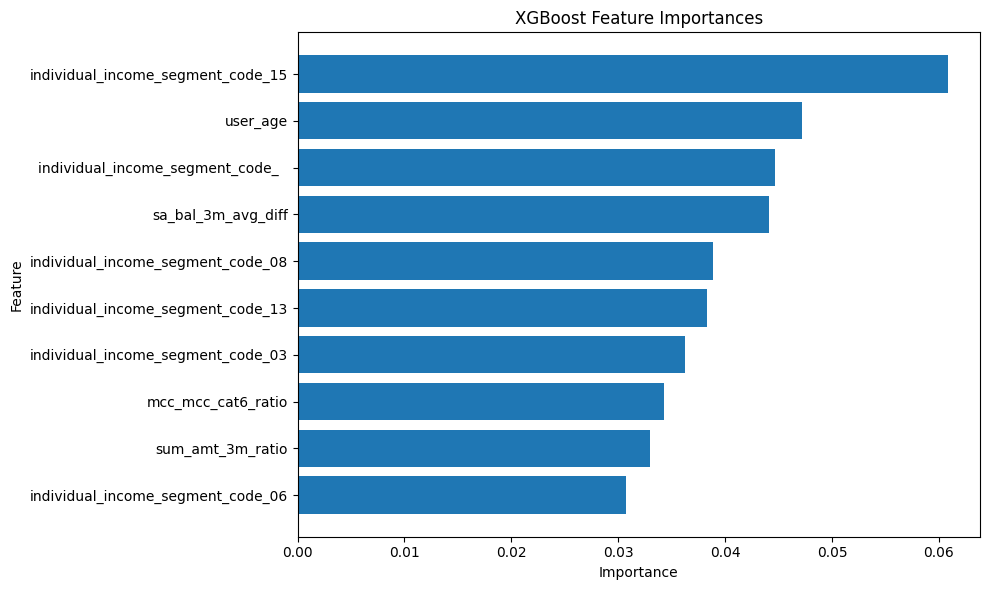

In [66]:
import matplotlib.pyplot as plt
feature_importance_df_10 = feature_importance_df.head(10)
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df_10['feature'],
    feature_importance_df_10['importance']
)

plt.gca().invert_yaxis()  # highest importance at the top
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()